# ARTI 403 Image Processing - Lab 1

In this lab, I practiced basic Python and used OpenCV, PIL, Matplotlib, and NumPy to load, display, save, and modify images.

## Step 0 - Install the required libraries

This cell is only needed if one of the libraries is not already installed.

In [1]:
# Remove the # from the next line if the libraries are missing.
# %pip install numpy matplotlib pillow opencv-python scikit-image

## Step 1 - Import the libraries and select the image

I selected the `camera` image because it is one of the images used in the provided `plot_general.ipynb` file.

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import skimage as ski

images_dir = Path('images')
images_dir.mkdir(exist_ok=True)

camera_path = images_dir / 'camera.tif'

# This is the same camera image listed in plot_general.ipynb.
selected_image = ski.data.camera()
Image.fromarray(selected_image).save(camera_path)

print('Selected image: camera')
print('Image path:', camera_path.resolve())

Selected image: camera
Image path: /Users/m.almarhoon/Image-Processing/Lab1/images/camera.tif


## Task 1 - Python basics

This is a short practice using a variable, list, loop, condition, and function.

In [3]:
course = 'ARTI 403'
pixel_values = [20, 80, 140, 200, 255]

def classify_pixel(value):
    if value < 128:
        return 'Dark'
    return 'Bright'

print('Course:', course)
for value in pixel_values:
    print(value, '->', classify_pixel(value))

Course: ARTI 403
20 -> Dark
80 -> Dark
140 -> Bright
200 -> Bright
255 -> Bright


## Task 2 - Load and display an image using OpenCV

`cv2.imread` loads the image as a NumPy array. OpenCV uses BGR order for color images, so a color image should be converted to RGB before displaying it with Matplotlib.

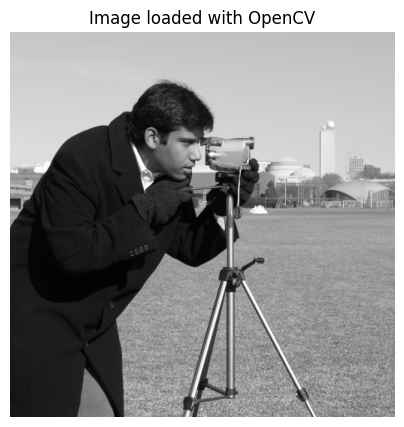

In [4]:
import cv2

img = cv2.imread(str(camera_path), cv2.IMREAD_UNCHANGED)
if img is None:
    raise FileNotFoundError(f'Could not read {camera_path}')

plt.figure(figsize=(5, 5))
if img.ndim == 2:
    plt.imshow(img, cmap='gray')
else:
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Image loaded with OpenCV')
plt.axis('off')
plt.show()

## Task 2 - Load and display an image using PIL

`Image.open` loads the image as a PIL Image object. Matplotlib is then used to display it.

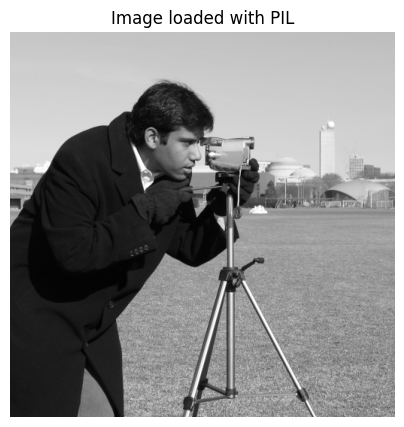

In [5]:
img2 = Image.open(camera_path)

plt.figure(figsize=(5, 5))
plt.imshow(img2, cmap='gray')
plt.title('Image loaded with PIL')
plt.axis('off')
plt.show()

## Task 3 - Save the images

The OpenCV image is saved with `cv2.imwrite`, while the PIL image is saved with the `save` method.

In [6]:
opencv_saved = cv2.imwrite('new_image.jpg', img)
img2.save('new_image2.jpg')

print('OpenCV save succeeded:', opencv_saved)
print('PIL image saved:', Path('new_image2.jpg').exists())

OpenCV save succeeded: True
PIL image saved: True


## Task 4 - Display the image as an array

A digital image is stored as numbers. In a grayscale image, each value represents brightness from 0 (black) to 255 (white).

In [7]:
print('OpenCV image shape:', img.shape)
print('OpenCV image data type:', img.dtype)
print('OpenCV array:\n', img)

img_array = np.array(img2)
print('\nPIL image converted to NumPy shape:', img_array.shape)
print('PIL/NumPy data type:', img_array.dtype)
print('PIL image as an array:\n', img_array)

OpenCV image shape: (512, 512)
OpenCV image data type: uint8
OpenCV array:
 [[200 200 200 ... 189 190 190]
 [200 199 199 ... 190 190 190]
 [199 199 199 ... 190 190 190]
 ...
 [ 25  25  27 ... 139 122 147]
 [ 25  25  26 ... 158 141 168]
 [ 25  25  27 ... 151 152 149]]

PIL image converted to NumPy shape: (512, 512)
PIL/NumPy data type: uint8
PIL image as an array:
 [[200 200 200 ... 189 190 190]
 [200 199 199 ... 190 190 190]
 [199 199 199 ... 190 190 190]
 ...
 [ 25  25  27 ... 139 122 147]
 [ 25  25  26 ... 158 141 168]
 [ 25  25  27 ... 151 152 149]]


## Assessment - NumPy operations

I used NumPy to find basic image statistics, increase brightness, flip the image, crop the center, and make a binary image. `clip` keeps pixel values between 0 and 255.

In [8]:
print('Minimum pixel:', img_array.min())
print('Maximum pixel:', img_array.max())
print('Mean intensity:', round(float(img_array.mean()), 2))
print('Standard deviation:', round(float(img_array.std()), 2))

bright = np.clip(img_array.astype(np.int16) + 50, 0, 255).astype(np.uint8)
flipped = np.fliplr(img_array)
h, w = img_array.shape[:2]
cropped = img_array[h // 4: 3 * h // 4, w // 4: 3 * w // 4]
binary = np.where(img_array >= 128, 255, 0).astype(np.uint8)

Minimum pixel: 0
Maximum pixel: 255
Mean intensity: 129.06
Standard deviation: 73.64


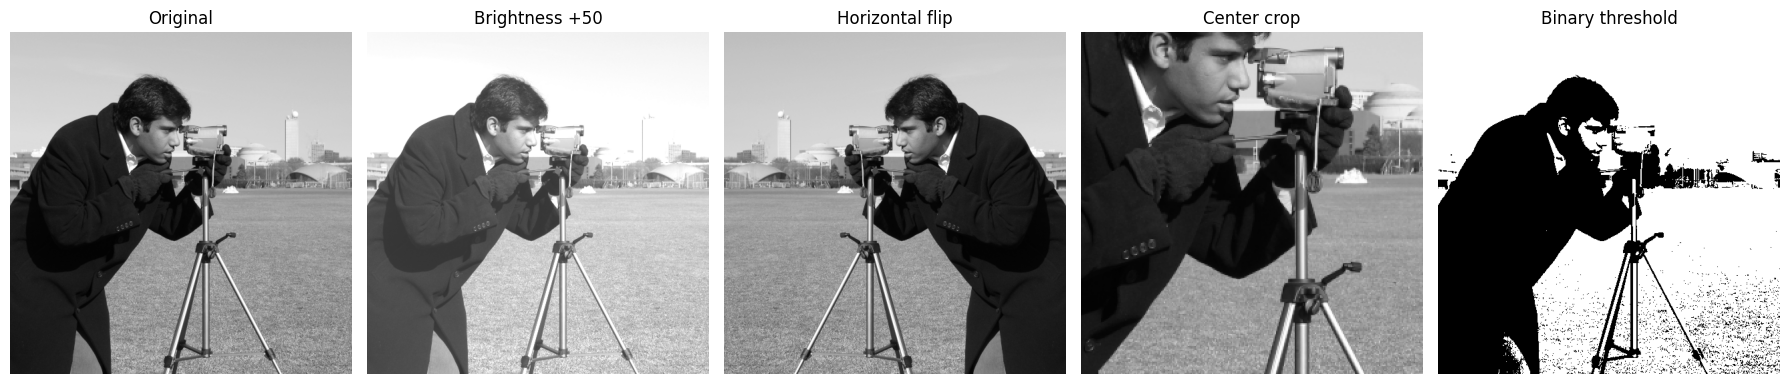

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
results = [
    (img_array, 'Original'),
    (bright, 'Brightness +50'),
    (flipped, 'Horizontal flip'),
    (cropped, 'Center crop'),
    (binary, 'Binary threshold'),
]

for ax, (result, title) in zip(axes, results):
    ax.imshow(result, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Result

The images were loaded with OpenCV and PIL and displayed with Matplotlib. I also saved new copies, printed the image arrays, and applied basic NumPy operations to the pixel values.